# Anndata object assembly and preprocessing
Mathieu Bourdenx - 2026

In [1]:
import os
import pandas as pd
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Paths

In [2]:
raw_data_path = '../data/raw_data'
processed_data_path = '../data/processed_data'

fig_path = '../figures/preprocessing'
os.makedirs(fig_path, exist_ok=True)

## Metadata

In [3]:
# Load demographics data
demographics = pd.read_excel(os.path.join(raw_data_path, 'scLCMdemographics.xlsx'), sheet_name='MB')

# ID matching proteomic dataseet
demographics['mergingID'] = [i[1:] for i in demographics['Path ID']]

# Subset demographics data to merge with sample metadata
subset_demographics = demographics[['mergingID', 'PMI hours', 'Age at death']]

In [ ]:
# Load all metadata
metadata = pd.read_csv(os.path.join(raw_data_path, 'metadata_ptau.csv'))

# 2 patient ID have been wrongly converted by Excel
metadata['patient'].replace('11-Aug', '8/11', inplace=True)
metadata['patient'].replace('16-Mar', '3/16', inplace=True)
metadata['patient'].replace('15/12', '5/12', inplace=True)

# Chech patient IDs
metadata['patient'].unique()

/var/folders/3_/3d2084dj4kdgndylxrd58s500000gn/T/ipykernel_11237/1752242048.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  metadata['patient'].replace('11-Aug', '8/11', inplace=True)
/var/folders/3_/3d2084dj4kdgndylxrd58s500000gn/T/ipykernel_11237/1752242048.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting 

## Build Mini Pools Anndata

In [5]:
# Load perseus imputed files
pool_data = pd.read_csv(os.path.join(raw_data_path, 'perseus_filtered_imputed_pooled.txt'), sep='\t', skiprows=1)

In [6]:
# Build anndata object
pool = ad.AnnData(X=pool_data.iloc[4:, :-4].T.astype('float'), obs=pool_data.T.iloc[:-4, :4], var=pool_data.iloc[4:, -4:])
pool.obs.columns = ['PatientTau', 'PatientID', 'Mode', 'TauStatus']
pool.var.columns = ['UniprotID', 'UniprotName', 'GeneName', 'Description']
pool

/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 48 × 5943
    obs: 'PatientTau', 'PatientID', 'Mode', 'TauStatus'
    var: 'UniprotID', 'UniprotName', 'GeneName', 'Description'

In [7]:
# Remove the DN samples
pool = pool[pool.obs['PatientID'] != 'DN']
pool

View of AnnData object with n_obs × n_vars = 44 × 5943
    obs: 'PatientTau', 'PatientID', 'Mode', 'TauStatus'
    var: 'UniprotID', 'UniprotName', 'GeneName', 'Description'

In [8]:
# Fix patient IDs
pool.obs['PatientID'].replace('15/12', '5/12', inplace=True)

/var/folders/3_/3d2084dj4kdgndylxrd58s500000gn/T/ipykernel_11237/3586816792.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pool.obs['PatientID'].replace('15/12', '5/12', inplace=True)


In [9]:
# Now merge with demographics
pool.obs = pd.merge(left=pool.obs, left_on='PatientID', right=subset_demographics, right_on='mergingID', how='left')

In [10]:
# Exclude contaminants
contaminant_to_exclude = [i for i in list(pool.var['UniprotID']) if 'Cont_' in str(i)]
print('N protein to exclude:' , len(contaminant_to_exclude))
pool = pool[:, ~pool.var['UniprotID'].isin(contaminant_to_exclude)]
pool

N protein to exclude: 90


View of AnnData object with n_obs × n_vars = 44 × 5853
    obs: 'PatientTau', 'PatientID', 'Mode', 'TauStatus', 'mergingID', 'PMI hours', 'Age at death'
    var: 'UniprotID', 'UniprotName', 'GeneName', 'Description'

In [11]:
# Fix Tau
tau_id = pool.var[pool.var['UniprotID'] == 'P10636'].index

pool.var.loc[tau_id, 'UniprotName'] = 'TAU_HUMAN'
pool.var.loc[tau_id, 'GeneName'] = 'MAPT'
pool.var.loc[tau_id, 'Description'] = 'Microtubule-associated protein tau'

In [12]:
# Check if still missing values 
pool.var.isna().sum()

UniprotID      0
UniprotName    0
GeneName       0
Description    0
dtype: int64

In [120]:
# Add phosphorylation data

b = metadata.reset_index(drop=True)
b.index = b.index.astype('str')

pool.obs = pd.merge(left=pool.obs, left_index=True, right=b, right_index=True, how='left')

In [121]:
# Save object
pool.write(os.path.join(processed_data_path, 'pool_processed.h5ad'))

## Build SingleCell AnnData

In [61]:
# Load perseus imputed files
sc_data = pd.read_csv(os.path.join(raw_data_path, 'perseus_filtered_imputed_single.txt'), sep='\t')

In [62]:
# Build anndata object
sc_ad = ad.AnnData(X=sc_data.iloc[6:, :-4].T.astype('float'), obs=sc_data.T.iloc[:-4, :6], var=sc_data.iloc[6:, -4:])
sc_ad.obs.columns = ['Sample_name', 'Plate', 'PatientTau', 'PatientID', 'Mode', 'TauStatus']
sc_ad.var.columns = ['UniprotID', 'UniprotName', 'GeneName', 'Description']

/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [63]:
# Set obs and var indices
sc_ad.obs['SampleID'] = sc_ad.obs.index
sc_ad.var.index = sc_ad.var['GeneName']

In [64]:
# Now merge with demographics
sc_ad.obs = pd.merge(left=sc_ad.obs, left_on='PatientID', right=subset_demographics, right_on='mergingID', how='left')

In [65]:
# Fix data type
sc_ad.obs['Plate'] = sc_ad.obs['Plate'].astype('str')

In [66]:
# Exclude contaminants
contaminant_to_exclude = [i for i in list(sc_ad.var['UniprotID']) if 'Cont_' in str(i)]

sc_ad = sc_ad[:, ~sc_ad.var['UniprotID'].isin(contaminant_to_exclude)]
sc_ad

View of AnnData object with n_obs × n_vars = 197 × 2131
    obs: 'Sample_name', 'Plate', 'PatientTau', 'PatientID', 'Mode', 'TauStatus', 'SampleID', 'mergingID', 'PMI hours', 'Age at death'
    var: 'UniprotID', 'UniprotName', 'GeneName', 'Description'

### Add Ubiquitin data

In [67]:
# Load ubiquitin data
ub = pd.read_csv(os.path.join(raw_data_path, 'ubi_data_new.csv'))

# Subset for single cell data
ub = ub[ub['mode'] == 'single']

In [69]:
# Add run column
for i in sc_ad.obs.index:
    sc_ad.obs.loc[i, 'Run'] = sc_ad.obs.loc[i, 'SampleID'].split('\\')[-1].split('.')[0]

In [70]:
# Merge with ubiquitin data
merged = pd.merge(left=sc_ad.obs, left_on='Run', right=ub[['Run', 'log2(intensity)']], right_on='Run', how='left')
merged.rename(columns={'log2(intensity)': 'intensity_ub'}, inplace=True)

### Add Phosphorylation data

In [73]:
# Load ptau data
sc_ptau = pd.read_csv(os.path.join(raw_data_path, 'metadata_ptau.csv'))

In [75]:
# Merge with phosphorylation metadata
sc_ad.obs = pd.merge(left=merged, left_on='SampleID', right=sc_ptau[['sample_name', 'pTau_202',	'pTau_217',	'pTau_231',	'pTau_404',	'pTau']], right_on='sample_name', how='left')

### Fix tau

In [53]:
sc_ad.var.reset_index(inplace=True, drop=True)

# Fix data type
sc_ad.var['UniprotID'] = sc_ad.var['UniprotID'].astype('str')
sc_ad.var['UniprotName'] = sc_ad.var['UniprotName'].astype('str')
sc_ad.var['GeneName'] = sc_ad.var['GeneName'].astype('str')
sc_ad.var['Description'] = sc_ad.var['Description'].astype('str')

In [55]:
# Fix Tau
tau_id = sc_ad.var[sc_ad.var['UniprotID'] == 'P10636'].index

sc_ad.var.loc[tau_id, 'UniprotName'] = 'TAU_HUMAN'
sc_ad.var.loc[tau_id, 'GeneName'] = 'MAPT'
sc_ad.var.loc[tau_id, 'Description'] = 'Microtubule-associated protein tau'

# Set gene name as index
sc_ad.var.index = sc_ad.var['GeneName']

### Filter tau levels

In [56]:
# Define 5th percentile
pct_cutoff = np.percentile(sc_ad[:, 'MAPT'].X.ravel(), q=(5))

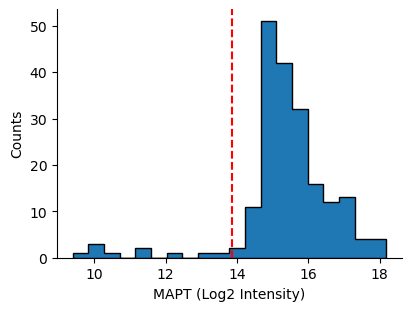

In [57]:
plt.figure(figsize=(4,3), constrained_layout=True)
plt.hist(sc_ad[:, 'MAPT'].X, bins=20, histtype='stepfilled', edgecolor='k')
plt.axvline(x=pct_cutoff, linestyle='dashed', c='r')
sns.despine()
plt.xlabel('MAPT (Log2 Intensity)')
plt.ylabel('Counts')
plt.savefig(os.path.join(fig_path, 'sc_mapt_levels.png'), dpi=300)
plt.show()

In [58]:
# Exclude cells with very low tau
cells_to_include = sc_ad[:, 'MAPT'].X > pct_cutoff
sc_ad = sc_ad[cells_to_include, :].copy()

/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


### Save object

In [59]:
sc_ad.write(os.path.join(processed_data_path, 'sc_processed.h5ad'))